In [ ]:
# Import libraries for numerical DSP work and plotting
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Define filter and sampling parameters
fs = 8000
fc = 1000
N = 21
M = (N - 1) // 2
wc = 2 * np.pi * fc / fs

In [ ]:
# Compute ideal low-pass impulse response
n = np.arange(N)
h_ideal = np.zeros(N)

for i in range(N):
    if i == M:
        h_ideal[i] = wc / np.pi
    else:
        h_ideal[i] = np.sin(wc * (i - M)) / (np.pi * (i - M))

In [ ]:
# Create Hamming window coefficients
hamming_window = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))

In [ ]:
# Apply Hamming window to ideal response
h = h_ideal * hamming_window

In [ ]:
# Compute frequency response of designed FIR filter
w = np.linspace(0, np.pi, 1024)
H = np.fft.fft(h, 1024)
H = H[:1024]
magnitude = np.abs(H)
phase = np.angle(H)
freq = np.linspace(0, fs / 2, 1024)

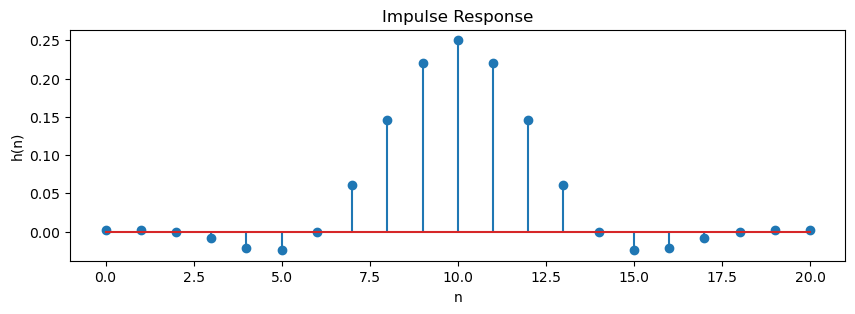

In [ ]:
# Plot impulse response of the FIR filter
plt.figure(figsize=(10, 3))
plt.stem(n, h)
plt.title('Impulse Response')
plt.xlabel('n')
plt.ylabel('h(n)')
plt.show()

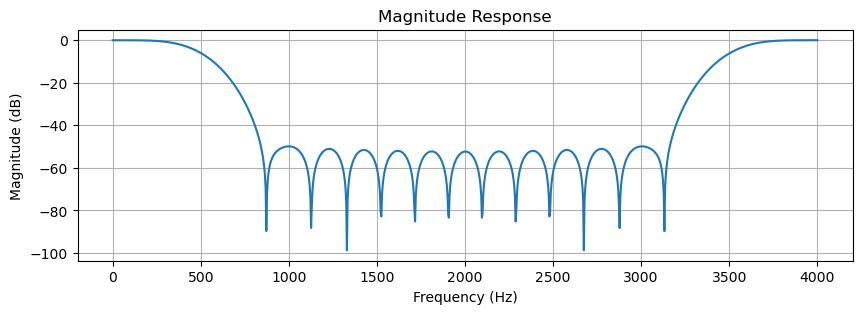

In [ ]:
# Plot normalized magnitude response in dB
plt.figure(figsize=(10, 3))
plt.plot(freq, 20 * np.log10(magnitude / np.max(magnitude)))
plt.title('Magnitude Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.show()

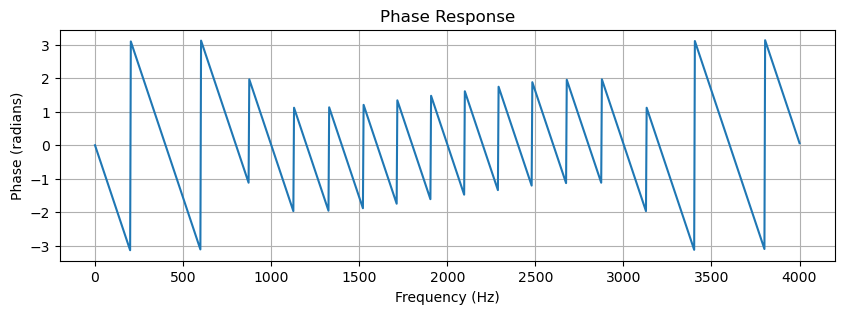

In [ ]:
# Plot phase response of the FIR filter
plt.figure(figsize=(10, 3))
plt.plot(freq, phase)
plt.title('Phase Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.grid(True)
plt.show()

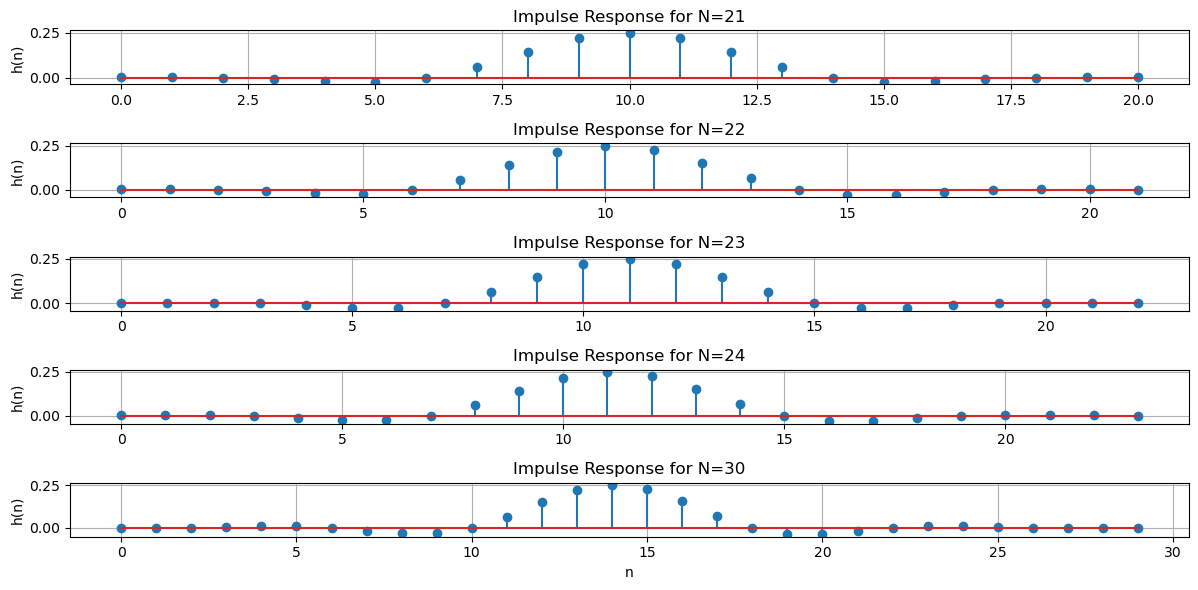

In [ ]:
# Compare impulse responses for different filter lengths
filter_lengths = [21, 22, 23, 24, 30]
plt.figure(figsize=(12, 6))
for idx, N_val in enumerate(filter_lengths):
    M_val = (N_val - 1) // 2
    n_val = np.arange(N_val)
    h_id = np.array([wc/np.pi if i == M_val else np.sin(wc*(i-M_val))/(np.pi*(i-M_val)) for i in range(N_val)])
    win = 0.54 - 0.46 * np.cos(2 * np.pi * n_val / (N_val - 1))
    h_win = h_id * win
    plt.subplot(len(filter_lengths), 1, idx+1)
    plt.stem(n_val, h_win)
    plt.title(f'Impulse Response for N={N_val}')
    plt.ylabel('h(n)')
    plt.grid(True)
plt.xlabel('n')
plt.tight_layout()
plt.show()

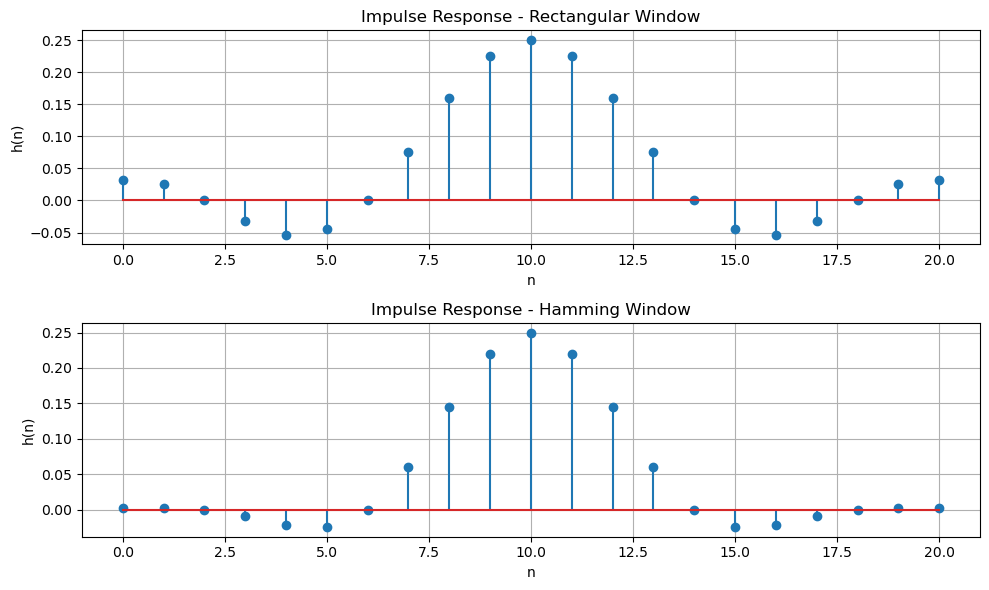

In [ ]:
# Compare rectangular and Hamming windowed FIR responses
n_val = np.arange(N)
h_id = np.array([wc/np.pi if i == M else np.sin(wc*(i-M))/(np.pi*(i-M)) for i in range(N)])

rect_win = np.ones(N)
hamm_win = 0.54 - 0.46 * np.cos(2 * np.pi * n_val / (N - 1))

h_rect = h_id * rect_win
h_hamm = h_id * hamm_win

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.stem(n_val, h_rect)
plt.title('Impulse Response - Rectangular Window')
plt.xlabel('n')
plt.ylabel('h(n)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(n_val, h_hamm)
plt.title('Impulse Response - Hamming Window')
plt.xlabel('n')
plt.ylabel('h(n)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Placeholder cell for additional FIR filter experiments
pass